In [1]:
import os
os.chdir("..")

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import torch
from autoencoder.model_qwen import QwenAutoencoder
from qwen_vl import *
from PIL import Image

In [3]:
base_dir = Path('output/cholecseg8k/video01_00080_qwen_cat')
data_dir = Path('data/cholecseg8k/preprocessed_ssg/video01/video01_00080/qwen_instance_features_dim3')
data_dir_f = Path('data/cholecseg8k/preprocessed_ssg/video01/video01_00080/qwen_patch_features_dim3')
img_dir = base_dir / 'video_rgb/ours_10000/gt'
gt_feat_dir = base_dir / 'video_lang/ours_10000/gt_npy'
render_feat_dir = base_dir / 'video_lang/ours_10000/renders_npy'

In [4]:
frame = 50

img = Image.open(img_dir / f'{frame:05}.png')
gt_feat = np.load(gt_feat_dir / f'{frame:05}.npy')[..., :3]
gt_patch_f = np.load(data_dir_f / f'{frame+1:06}_f.npy')
render_feat = np.load(render_feat_dir / f'{frame:05}.npy')[..., :3]
seg = np.load(data_dir / f'{frame+1:06}_s.npy')[0]
gt_patch_feat = gt_patch_f.reshape(17, 20, 3)

In [5]:
col_transform = lambda c: c/2+0.5

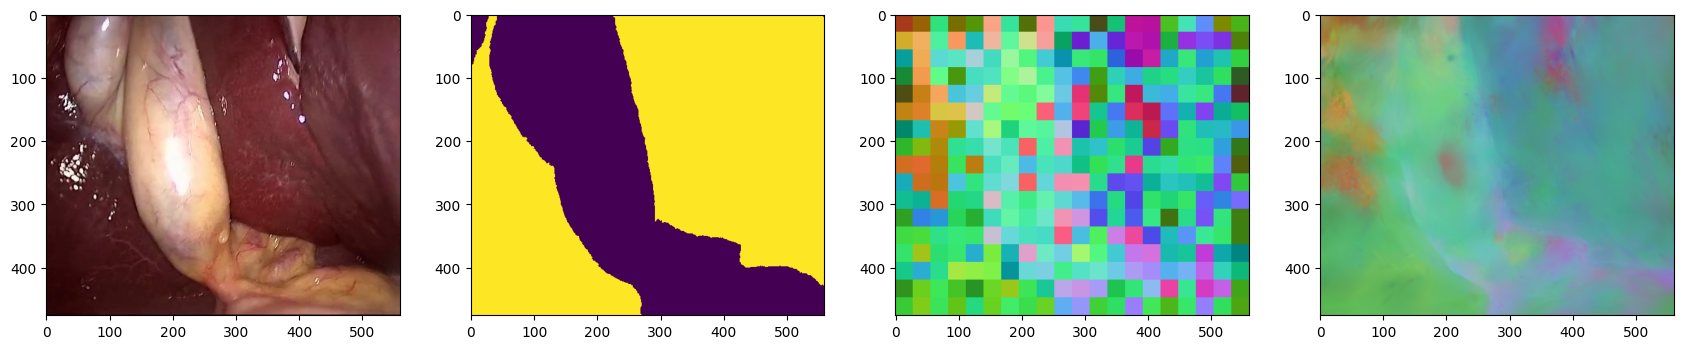

In [6]:
fig, axs = plt.subplots(1, 4, figsize=(21, 9))
axs[0].imshow(img)
axs[1].imshow(seg == 2)
axs[2].imshow(col_transform(gt_feat))
axs[3].imshow(col_transform(render_feat))
plt.show()

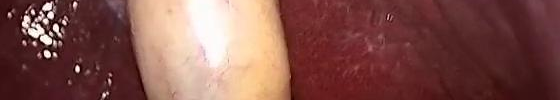

In [7]:
img.crop((0, 220, img.width, 320))

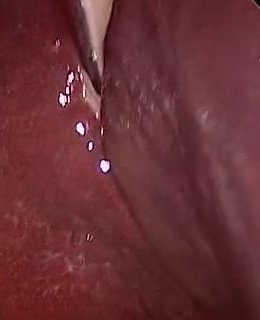

In [8]:
img.crop((300, 0, img.width, 320))

In [9]:
selected_seg_id = 2

In [10]:
patch_coords = np.meshgrid(np.arange(0, img.height // 28), np.arange(0, img.width // 28), indexing='ij')
patch_centers = np.meshgrid(np.arange(0, img.height, 28)+14, np.arange(0, img.width, 28)+14, indexing='ij')
patch_seg = seg[patch_centers[0], patch_centers[1]]
# seg_patches = np.stack(patch_coords, axis=-1).reshape(-1, 2)[seg.ravel() == selected_seg_id]

In [11]:
seg_upper_crop = (patch_seg == selected_seg_id).any(axis=1).argmax()
seg_lower_crop = (patch_seg == selected_seg_id).any(axis=1)[::-1].argmax()
seg_left_crop = (patch_seg == selected_seg_id).any(axis=0).argmax()
seg_right_crop = (patch_seg == selected_seg_id).any(axis=0)[::-1].argmax()

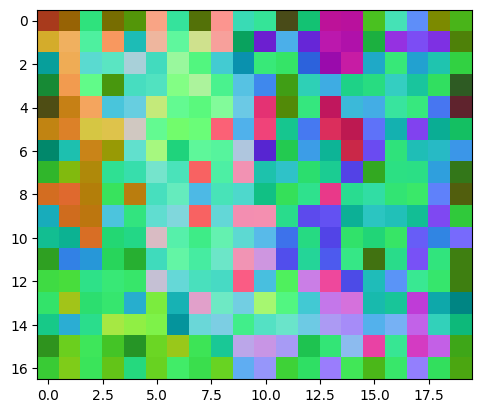

In [12]:
seg_crop_feats = gt_patch_feat[seg_upper_crop:17-seg_lower_crop+1, seg_left_crop:20-seg_right_crop+1]
plt.imshow(col_transform(seg_crop_feats))
plt.show()

In [13]:
seg_feats = gt_patch_feat.reshape(-1, 3)[patch_seg.ravel() == selected_seg_id]

In [14]:
seg_feats.shape

(212, 3)

In [15]:
selected_seg_centers = np.stack(patch_centers, axis=-1).reshape(-1, 2)[patch_seg.ravel() == selected_seg_id]

In [16]:
render_seg_feats = render_feat[selected_seg_centers[:,0], selected_seg_centers[:,1]]

In [17]:
model, processor = get_patched_qwen(use_bnb_4bit=False)
ae_ckpt_path = Path('data/cholecseg8k/preprocessed_ssg/video01/video01_00080/autoencoder/best_ckpt.pth')
ae = QwenAutoencoder(latent_dim=3).to("cuda")
ae.load_state_dict(torch.load(ae_ckpt_path))
ae.eval()
pass

Loading checkpoint shards:   0%|          | 0/5 [00:00<?, ?it/s]

OutOfMemoryError: CUDA out of memory. Tried to allocate 130.00 MiB. GPU 0 has a total capacity of 23.46 GiB of which 8.88 MiB is free. Process 2902611 has 11.62 GiB memory in use. Including non-PyTorch memory, this process has 11.83 GiB memory in use. Of the allocated memory 11.65 GiB is allocated by PyTorch, and 20.08 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
ask_qwen_about_image(img.crop((300, 0, img.width, 320)), "Is this the gallbladder or the liver?", model, processor, system_prompt="You are a medical expert with a special expertise in distinguishing pictures of the gallbladder and the liver. When shown an image, you will decide which organ is shown.")

"The image shows a close-up view of skin with some liquid droplets on it. This does not appear to be an image of either the gallbladder or the liver. These organs are internal and would typically be visible only through imaging techniques like ultrasound or MRI, not through a close-up of the skin. The image appears to be of a person's skin, possibly after a procedure or treatment where liquid has been applied."

In [ ]:
# crop features
ask_qwen_about_image_features(
    ae.decode(torch.tensor(seg_crop_feats.reshape(-1, 3), device='cuda')),
    "Which organ is this?", model, processor
)

'This image shows the gallbladder, which is a small, pear-shaped organ located under the liver on the right side of the upper abdomen. It stores and concentrates bile, a digestive fluid that helps break down fats in the small intestine.'

In [ ]:
# mask features
ask_qwen_about_image_features(
    ae.decode(torch.tensor(seg_feats, device='cuda')),
    "Which organ is this?", model, processor
)

'This image shows the gallbladder.'

In [ ]:
# rendered mask features
ask_qwen_about_image_features(
    ae.decode(torch.tensor(render_seg_feats, device='cuda')),
    "Which organ is this?", model, processor
)

'This image shows the gallbladder.'